In [20]:
#import 
import torch
import json
from torch_geometric.data import DataLoader
from matplotlib_venn import venn3
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import roc_auc_score
from sklearn.metrics import recall_score, confusion_matrix
from networks import GAT, PPGAT
import pickle
import numpy as np
import random

In [21]:
#set random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

In [22]:
def evaluate_and_get_correct(model, loader, device='cuda', threshold=0.5):
    """
    Evaluate a model and return predictions, raw outputs, labels, and molecule info.
    
    Returns:
        preds_binary: thresholded (0/1) predictions
        labels: ground truth labels
        correct_mols: correctly predicted molecules
        incorrect_mols: incorrectly predicted molecules
        correct_active_mols: correctly predicted actives
        raw_outputs: raw model logits (before sigmoid)
    """
    model.eval()
    all_preds_binary = []
    all_labels = []
    all_raw_outputs = []
    correct_mols = []
    incorrect_mols = []
    correct_active_mols = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)                      # raw logits
            raw_outputs = out.view(-1)              # flatten logits
            preds = (torch.sigmoid(raw_outputs) > threshold).float()  # thresholded binary preds
            labels = batch.y.float().view(-1)

            all_preds_binary.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_raw_outputs.append(raw_outputs.cpu())

            mols = batch.to_data_list()
            for i in range(len(labels)):
                if preds[i] == labels[i]:
                    correct_mols.append(mols[i])
                    if labels[i] == 1:
                        correct_active_mols.append(mols[i])
                else:
                    incorrect_mols.append(mols[i])

    # Combine all predictions
    all_preds_binary = torch.cat(all_preds_binary)
    all_labels = torch.cat(all_labels)
    all_raw_outputs = torch.cat(all_raw_outputs)

    return all_preds_binary, all_labels, correct_mols, incorrect_mols, correct_active_mols, all_raw_outputs


In [23]:
with open('datasets/df_random_vs_st_dataset_revised.pkl', 'rb') as f:
    data = pickle.load(f)
targets = data['accession'].unique()
targets

array(['P08581', 'P35968', 'Q16790', 'P56817', 'P22303', 'P06276',
       'P00915', 'P34913', 'Q13547', 'P27487'], dtype=object)

In [31]:
#load datasets
target = 'Q13547'
dataset = torch.load(f'datasets/Gdatasets/{target}_dataset.pt', weights_only=False)
rg_dataset = torch.load(f'datasets/RGdatasets/{target}_RG_dataset.pt', weights_only=False)
ppgat_dataset = torch.load(f'datasets/PPGATdatasets/{target}_PPGAT_dataset.pt', weights_only=False)

In [32]:
# GAT -mol

with open(f"results/models/gat/{target}/best_config.json", "r") as f:
    best_config = json.load(f)

lr = best_config["lr"]
batch_size = best_config["batch_size"]
print("Loaded config gat-mol:", best_config)


in_channels = dataset[0].x.size(-1)
edge_attr_dim = dataset[0].edge_attr.size(-1)
out_channels = 1
gat_model = GAT(in_channels, edge_attr_dim, hidden_channels=64, out_channels=out_channels).to("cuda")

# Load trained weights
gat_model.load_state_dict(torch.load(f"results/models/gat/{target}/best_model.pt", map_location="cuda"))
gat_model.eval()


# Load test dataset
gat_test_set = torch.load(f"results/models/gat/{target}/test_dataset.pt", weights_only=False)

# EVALUATE MODEL 

test_loader = DataLoader(gat_test_set, batch_size=batch_size, shuffle=False)
gat_preds, gat_labels, gat_correct_mols, gat_incorrect_mols, gat_correct_active_mols, all_raw_outputs = evaluate_and_get_correct(gat_model, test_loader, device='cuda')

print(len(gat_correct_mols))
print(len(gat_incorrect_mols))

gat_accuracy = (gat_preds == gat_labels).float().mean().item()
print(f"Test Accuracy: {gat_accuracy:.4f}")

print()
gat_probs = torch.sigmoid(all_raw_outputs).cpu().numpy()
gat_labels_np = gat_labels.cpu().numpy()

gat_auroc = roc_auc_score(gat_labels_np, gat_probs)
print(f"Test AUROC: {gat_auroc:.4f}")


Loaded config gat-mol: {'lr': 0.001, 'batch_size': 32}


/home/tejaurrutoam1/.conda/envs/pyg_v3/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


739
73
Test Accuracy: 0.9101

Test AUROC: 0.9844


In [33]:
#GAT -rg

with open(f"results/models/gat_rg/{target}/best_config.json", "r") as f:
    best_config = json.load(f)

lr = best_config["lr"]
batch_size = best_config["batch_size"]

print("Loaded config:", best_config)


in_channels = dataset[0].x.size(-1)
edge_attr_dim = dataset[0].edge_attr.size(-1)
out_channels = 1


# Initialize model
gat_rg_model = GAT(in_channels, edge_attr_dim, hidden_channels=64, out_channels=out_channels).to("cuda")

# Load trained weightss
gat_rg_model.load_state_dict(torch.load(f"results/models/gat_rg/{target}/best_model.pt", map_location="cuda"))
gat_rg_model.eval()

# Load test dataset
gat_rg_test = torch.load(f"results/models/gat_rg/{target}/test_dataset.pt", weights_only=False)

# EVALUATE MODEL 

test_loader = DataLoader(gat_rg_test, batch_size=32, shuffle=False)

gat_rg_preds, gat_rg_labels, gat_rg_correct_mols, gat_rg_incorrect_mols, gat_rg_correct_active_mols, rg_raw_outputs = evaluate_and_get_correct(gat_rg_model, test_loader, device='cuda')
print(len(gat_rg_correct_mols))
print(len(gat_rg_incorrect_mols))

gat_rg_accuracy = (gat_rg_preds == gat_rg_labels).float().mean().item()
print(f"Test Accuracy: {gat_rg_accuracy:.4f}")

print()
gat_rg_probs = torch.sigmoid(rg_raw_outputs).cpu().numpy()
gat_rg_labels_np = gat_rg_labels.cpu().numpy()

gat_rg_auroc = roc_auc_score(gat_rg_labels_np, gat_rg_probs)
print(f"Test AUROC: {gat_rg_auroc:.4f}")


Loaded config: {'lr': 0.001, 'batch_size': 16}


/home/tejaurrutoam1/.conda/envs/pyg_v3/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


794
18
Test Accuracy: 0.9778

Test AUROC: 0.9914


In [34]:
#LOAD MODEL 

with open(f"results/models/ppgat/{target}/best_config.json", "r") as f:
    best_config = json.load(f)

lr = best_config["lr"]
batch_size = best_config["batch_size"]

print("Loaded config:", best_config)


in_channels = dataset[0].x.size(-1)
edge_attr_dim = dataset[0].edge_attr.size(-1)
out_channels = 1


# Initialize model
rgnn_model = PPGAT(in_channels, edge_attr_dim, hidden_channels=64, out_channels=out_channels).to("cuda")

# Load trained weights
rgnn_model.load_state_dict(torch.load(f"results/models/ppgat/{target}/best_model.pt", map_location="cuda"))
rgnn_model.eval()
f
# Load test dataset
rgnn_test = torch.load(f"results/models/ppgat/{target}/test_dataset.pt", weights_only=False)

# EVALUATE MODEL 
test_loader = DataLoader(rgnn_test, batch_size=32, shuffle=False)

rgnn_preds, rgnn_labels, rgnn_correct_mols, rgnn_incorrect_mols, rgnn_correct_active_mols, rgnn_raw_outputs = evaluate_and_get_correct(rgnn_model, test_loader, device='cuda')

print(len(rgnn_correct_mols))
print(len(rgnn_incorrect_mols))
rgnn_accuracy = (rgnn_preds == gat_rg_labels).float().mean().item()
print(f"Test Accuracy: {rgnn_accuracy:.4f}")


print()
rgnn_probs = torch.sigmoid(rgnn_raw_outputs).cpu().numpy()
rgnn_labels_np = rgnn_labels.cpu().numpy()

rgnn_auroc = roc_auc_score(rgnn_labels_np, rgnn_probs)
print(f"Test AUROC: {rgnn_auroc:.4f}")


Loaded config: {'lr': 0.001, 'batch_size': 16}


/home/tejaurrutoam1/.conda/envs/pyg_v3/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


792
20
Test Accuracy: 0.9754

Test AUROC: 0.9827


analysis

In [35]:
gat_rg_labels = gat_rg_labels.long()
counts = torch.bincount(gat_rg_labels)

inactive = counts[0].item()
active = counts[1].item()

print(f"Active: {active}, Inactive: {inactive}")

Active: 406, Inactive: 406


In [36]:
#set of smiles of active molecules correcly predicted by each model
correct_act_gat = {data.smiles for data in gat_correct_active_mols}
correct_act_gat_rg = {data.smiles for data in gat_rg_correct_active_mols}
correct_act_rgnn = {data.smiles for data in rgnn_correct_active_mols}

#intersection
common_correct_active_smiles = correct_act_gat & correct_act_gat_rg & correct_act_rgnn



print("Active")
print('correctly predicted by GAT-mol:',len(correct_act_gat))
print('correctly predicted by GAT-rg:',len(correct_act_gat_rg))
print('correctly predicted by RGNN:',len(correct_act_rgnn))
print()
print('Active compounds correctly predicted by all three models:',len(common_correct_active_smiles))
total_correct = correct_act_gat | correct_act_gat_rg | correct_act_rgnn
print('Total number of active molecules identified:' , len(total_correct))
print('Active compounds missed by all three models:' , active -len(total_correct))


# correct molecules
correct_gat = {data.smiles for data in gat_correct_mols}
correct_gat_rg = {data.smiles for data in gat_rg_correct_mols}
correct_rgnn = {data.smiles for data in rgnn_correct_mols}

#correct inactive
correct_inactive_gat = set(correct_gat) - set(correct_act_gat)
correct_inactive_gat_rg = set(correct_gat_rg) - set(correct_act_gat_rg)
correct_inactive_rgnn = set(correct_rgnn) - set(correct_act_rgnn)

common_correct_inactive_smiles = correct_inactive_gat & correct_inactive_gat_rg & correct_inactive_rgnn





print()
print("Inactive")
print('Correctly predicted by GAT-mol:',len(correct_inactive_gat))
print('Correctly predicted by GAT-rg:',len(correct_inactive_gat_rg))
print('Correctly predicted by RGNN:',len(correct_inactive_rgnn))
print()
print('Inactive compounds correctly predicted by all three models:',len(common_correct_inactive_smiles))
total_correct_inactive = correct_inactive_gat | correct_inactive_gat_rg | correct_inactive_rgnn
print('Total number of inactive molecules identified:' , len(total_correct_inactive))
print('Inactive compounds missed by all three models:' , inactive -len(total_correct_inactive))


Active
correctly predicted by GAT-mol: 342
correctly predicted by GAT-rg: 400
correctly predicted by RGNN: 401

Active compounds correctly predicted by all three models: 337
Total number of active molecules identified: 404
Active compounds missed by all three models: 2

Inactive
Correctly predicted by GAT-mol: 397
Correctly predicted by GAT-rg: 394
Correctly predicted by RGNN: 391

Inactive compounds correctly predicted by all three models: 387
Total number of inactive molecules identified: 399
Inactive compounds missed by all three models: 7


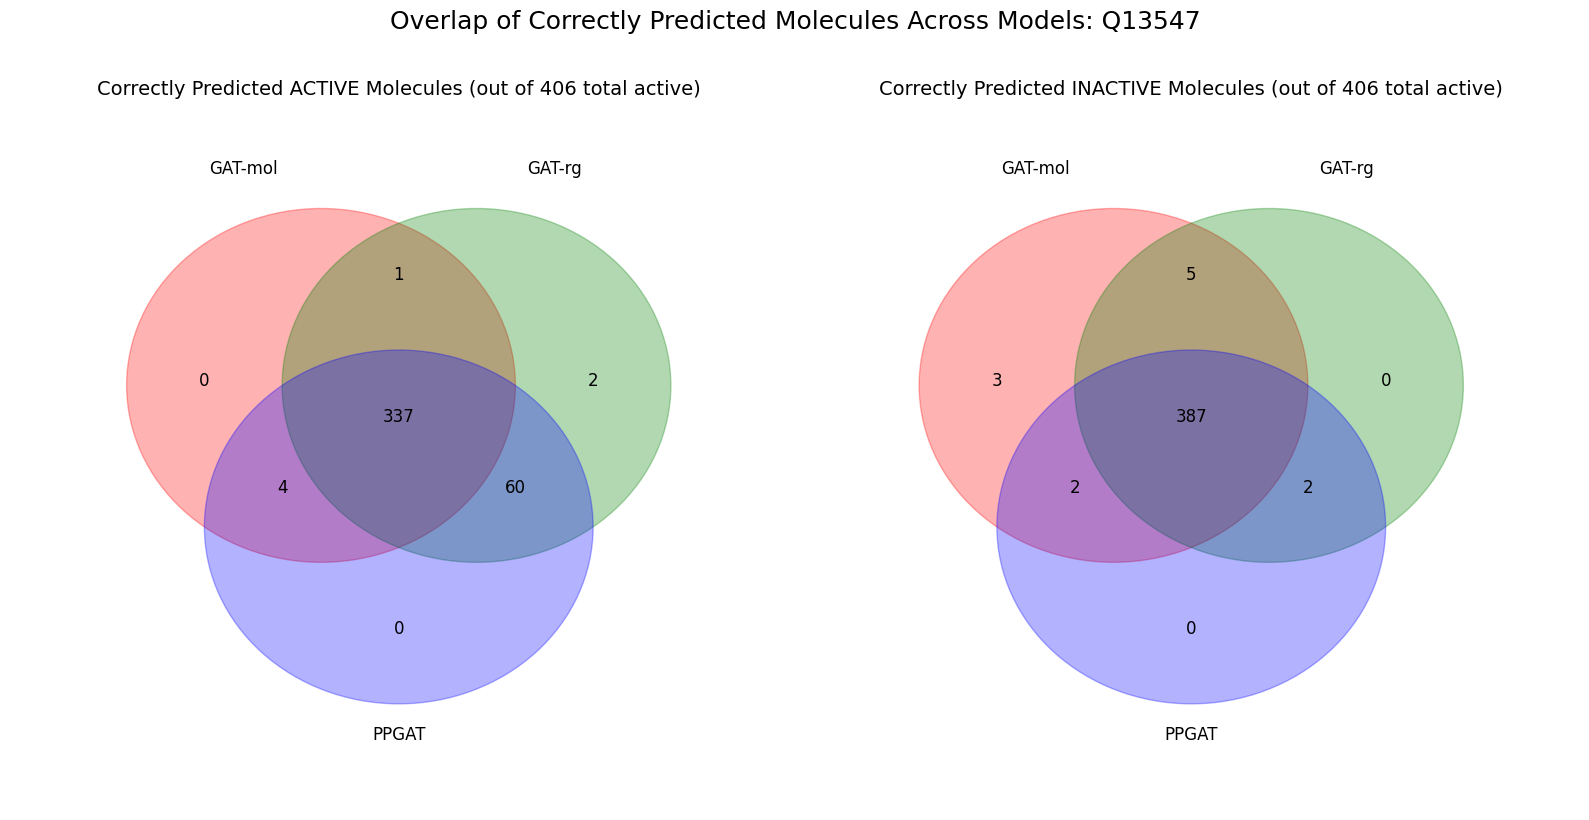

In [37]:
#VENN DIAGRAM 


# --- ACTIVE MOLECULES ---
only_GAT_act = correct_act_gat - (correct_act_gat_rg | correct_act_rgnn)
only_GAT_rg_act = correct_act_gat_rg - (correct_act_gat | correct_act_rgnn)
only_RGNN_act = correct_act_rgnn - (correct_act_gat | correct_act_gat_rg)

GAT_GAT_rg_act = (correct_act_gat & correct_act_gat_rg) - correct_act_rgnn
GAT_RGNN_act = (correct_act_gat & correct_act_rgnn) - correct_act_gat_rg
GAT_rg_RGNN_act = (correct_act_gat_rg & correct_act_rgnn) - correct_act_gat
all_three_act = correct_act_gat & correct_act_gat_rg & correct_act_rgnn

# --- INACTIVE MOLECULES ---
only_GAT_inact = correct_inactive_gat - (correct_inactive_gat_rg | correct_inactive_rgnn)
only_GAT_rg_inact = correct_inactive_gat_rg - (correct_inactive_gat | correct_inactive_rgnn)
only_RGNN_inact = correct_inactive_rgnn - (correct_inactive_gat | correct_inactive_gat_rg)

GAT_GAT_rg_inact = (correct_inactive_gat & correct_inactive_gat_rg) - correct_inactive_rgnn
GAT_RGNN_inact = (correct_inactive_gat & correct_inactive_rgnn) - correct_inactive_gat_rg
GAT_rg_RGNN_inact = (correct_inactive_gat_rg & correct_inactive_rgnn) - correct_inactive_gat
all_three_inact = correct_inactive_gat & correct_inactive_gat_rg & correct_inactive_rgnn

# --- Plot both side by side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Common circle layout
def draw_venn(ax, counts, title, labels=("GAT-mol", "GAT-rg", "PPGAT")):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    r = 2.5

    circle1 = plt.Circle((4, 6), r, color='red', alpha=0.3)
    circle2 = plt.Circle((6, 6), r, color='green', alpha=0.3)
    circle3 = plt.Circle((5, 4), r, color='blue', alpha=0.3)

    for c in (circle1, circle2, circle3):
        ax.add_patch(c)

    (only_A, only_B, only_C, AB, AC, BC, ABC) = counts

    # Individual sets
    ax.text(2.5, 6, str(len(only_A)), fontsize=12, ha='center')
    ax.text(7.5, 6, str(len(only_B)), fontsize=12, ha='center')
    ax.text(5, 2.5, str(len(only_C)), fontsize=12, ha='center')

    # Pairwise intersections
    ax.text(5, 7.5, str(len(AB)), fontsize=12, ha='center')
    ax.text(3.5, 4.5, str(len(AC)), fontsize=12, ha='center')
    ax.text(6.5, 4.5, str(len(BC)), fontsize=12, ha='center')

    # Triple intersection
    ax.text(5, 5.5, str(len(ABC)), fontsize=12, ha='center')

    # Labels
    ax.text(3, 9, labels[0], fontsize=12, ha='center')
    ax.text(7, 9, labels[1], fontsize=12, ha='center')
    ax.text(5, 1.0, labels[2], fontsize=12, ha='center')

    ax.set_title(title, fontsize=14)
    ax.axis('off')

# --- Draw both diagrams ---
draw_venn(
    ax1,
    (only_GAT_act, only_GAT_rg_act, only_RGNN_act, GAT_GAT_rg_act, GAT_RGNN_act, GAT_rg_RGNN_act, all_three_act),
    f"Correctly Predicted ACTIVE Molecules (out of {active} total active)"
)

draw_venn(
    ax2,
    (only_GAT_inact, only_GAT_rg_inact, only_RGNN_inact, GAT_GAT_rg_inact, GAT_RGNN_inact, GAT_rg_RGNN_inact, all_three_inact),
    f"Correctly Predicted INACTIVE Molecules (out of {active} total active)"
)

plt.suptitle(f"Overlap of Correctly Predicted Molecules Across Models: {target}", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(f"results/venns/venn_comparison_{target}.png", dpi=300, bbox_inches='tight')
plt.show()